In [12]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import rasterio
import warnings
warnings.filterwarnings('ignore')

In [13]:
FIELD_ID = 30387
DATASET_ROOT = Path('/home/johan/Thesis/Sentinel_1/ost/s1/S1_Timeseries/dataset')
FIELD_DIR = DATASET_ROOT / 'data' / str(FIELD_ID)
print(f'Field directory: {FIELD_DIR}')
print(f'Exists: {FIELD_DIR.exists()}')
print(f'Files: {sorted([f.name for f in FIELD_DIR.glob("*.tif")])}')

Field directory: /home/johan/Thesis/Sentinel_1/ost/s1/S1_Timeseries/dataset/data/30387
Exists: True
Files: ['mask_30387.tif', 's1_bs_20240607_30387.tif', 's1_bs_20240619_30387.tif', 's1_bs_20240701_30387.tif', 's1_bs_20240713_30387.tif', 's1_bs_20240725_30387.tif', 's1_bs_20240806_30387.tif', 's1_bs_20240818_30387.tif', 's1_bs_20240830_30387.tif', 's1_dprvi_20240607_30387.tif', 's1_dprvi_20240619_30387.tif', 's1_dprvi_20240701_30387.tif', 's1_dprvi_20240713_30387.tif', 's1_dprvi_20240725_30387.tif', 's1_dprvi_20240806_30387.tif', 's1_dprvi_20240818_30387.tif', 's1_dprvi_20240830_30387.tif', 's1_pol_20240607_30387.tif', 's1_pol_20240619_30387.tif', 's1_pol_20240701_30387.tif', 's1_pol_20240713_30387.tif', 's1_pol_20240725_30387.tif', 's1_pol_20240806_30387.tif', 's1_pol_20240818_30387.tif', 's1_pol_20240830_30387.tif']


In [14]:
mask_file = list(FIELD_DIR.glob('mask_*'))[0]
print(f'Loading: {mask_file.name}')
with rasterio.open(mask_file) as src:
    mask_data = src.read(1)
print(f'Mask shape: {mask_data.shape}, values: {np.unique(mask_data)}')

Loading: mask_30387.tif
Mask shape: (100, 76), values: [0 1]


In [15]:
def find_files(field_dir, field_id, product):
    files = {}
    pattern = f'{product}_*_{field_id}.tif'
    print(f'Looking for: {pattern}')
    for tif in sorted(field_dir.glob(pattern)):
        for part in tif.stem.split('_'):
            if len(part) == 8 and part.isdigit():
                date_obj = datetime.strptime(part, '%Y%m%d')
                files[date_obj] = tif
                print(f'  Found: {tif.name}')
                break
    return dict(sorted(files.items()))

bs_files = find_files(FIELD_DIR, FIELD_ID, 's1_bs')
pol_files = find_files(FIELD_DIR, FIELD_ID, 's1_pol')
dprvi_files = find_files(FIELD_DIR, FIELD_ID, 's1_dprvi')
print(f'\nBS: {len(bs_files)} dates | POL: {len(pol_files)} dates | DpRVI: {len(dprvi_files)} dates')

Looking for: s1_bs_*_30387.tif
  Found: s1_bs_20240607_30387.tif
  Found: s1_bs_20240619_30387.tif
  Found: s1_bs_20240701_30387.tif
  Found: s1_bs_20240713_30387.tif
  Found: s1_bs_20240725_30387.tif
  Found: s1_bs_20240806_30387.tif
  Found: s1_bs_20240818_30387.tif
  Found: s1_bs_20240830_30387.tif
Looking for: s1_pol_*_30387.tif
  Found: s1_pol_20240607_30387.tif
  Found: s1_pol_20240619_30387.tif
  Found: s1_pol_20240701_30387.tif
  Found: s1_pol_20240713_30387.tif
  Found: s1_pol_20240725_30387.tif
  Found: s1_pol_20240806_30387.tif
  Found: s1_pol_20240818_30387.tif
  Found: s1_pol_20240830_30387.tif
Looking for: s1_dprvi_*_30387.tif
  Found: s1_dprvi_20240607_30387.tif
  Found: s1_dprvi_20240619_30387.tif
  Found: s1_dprvi_20240701_30387.tif
  Found: s1_dprvi_20240713_30387.tif
  Found: s1_dprvi_20240725_30387.tif
  Found: s1_dprvi_20240806_30387.tif
  Found: s1_dprvi_20240818_30387.tif
  Found: s1_dprvi_20240830_30387.tif

BS: 8 dates | POL: 8 dates | DpRVI: 8 dates


In [16]:
def load_data(files):
    data = {}
    for date, path in files.items():
        with rasterio.open(path) as src:
            data[date] = src.read()
    return data

bs_data = load_data(bs_files)
pol_data = load_data(pol_files)
dprvi_data = load_data(dprvi_files)

# Normalize Entropy band (band 0) from 0-100 to 0-1
for date in pol_data.keys():
    pol_data[date][0] = pol_data[date][0] / 100.0

print(f'Loaded BS: {len(bs_data)} | POL: {len(pol_data)} | DpRVI: {len(dprvi_data)}')

Loaded BS: 8 | POL: 8 | DpRVI: 8


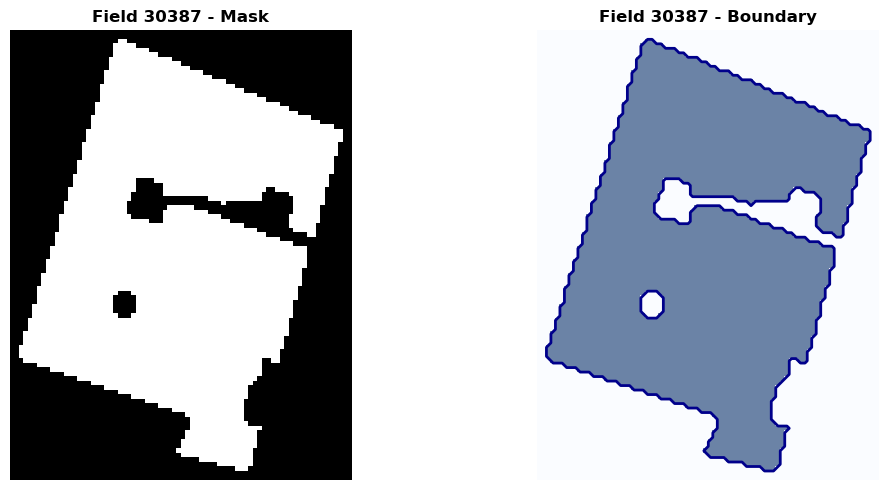

Saved: field_mask.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(mask_data, cmap='gray')
axes[0].set_title(f'Field {FIELD_ID} - Mask', fontweight='bold')
axes[0].axis('off')
axes[1].imshow(mask_data, cmap='Blues', alpha=0.6)
axes[1].contour(mask_data, levels=[0.5], colors='darkblue', linewidths=2)
axes[1].set_title(f'Field {FIELD_ID} - Boundary', fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('field_mask.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: field_mask.png')

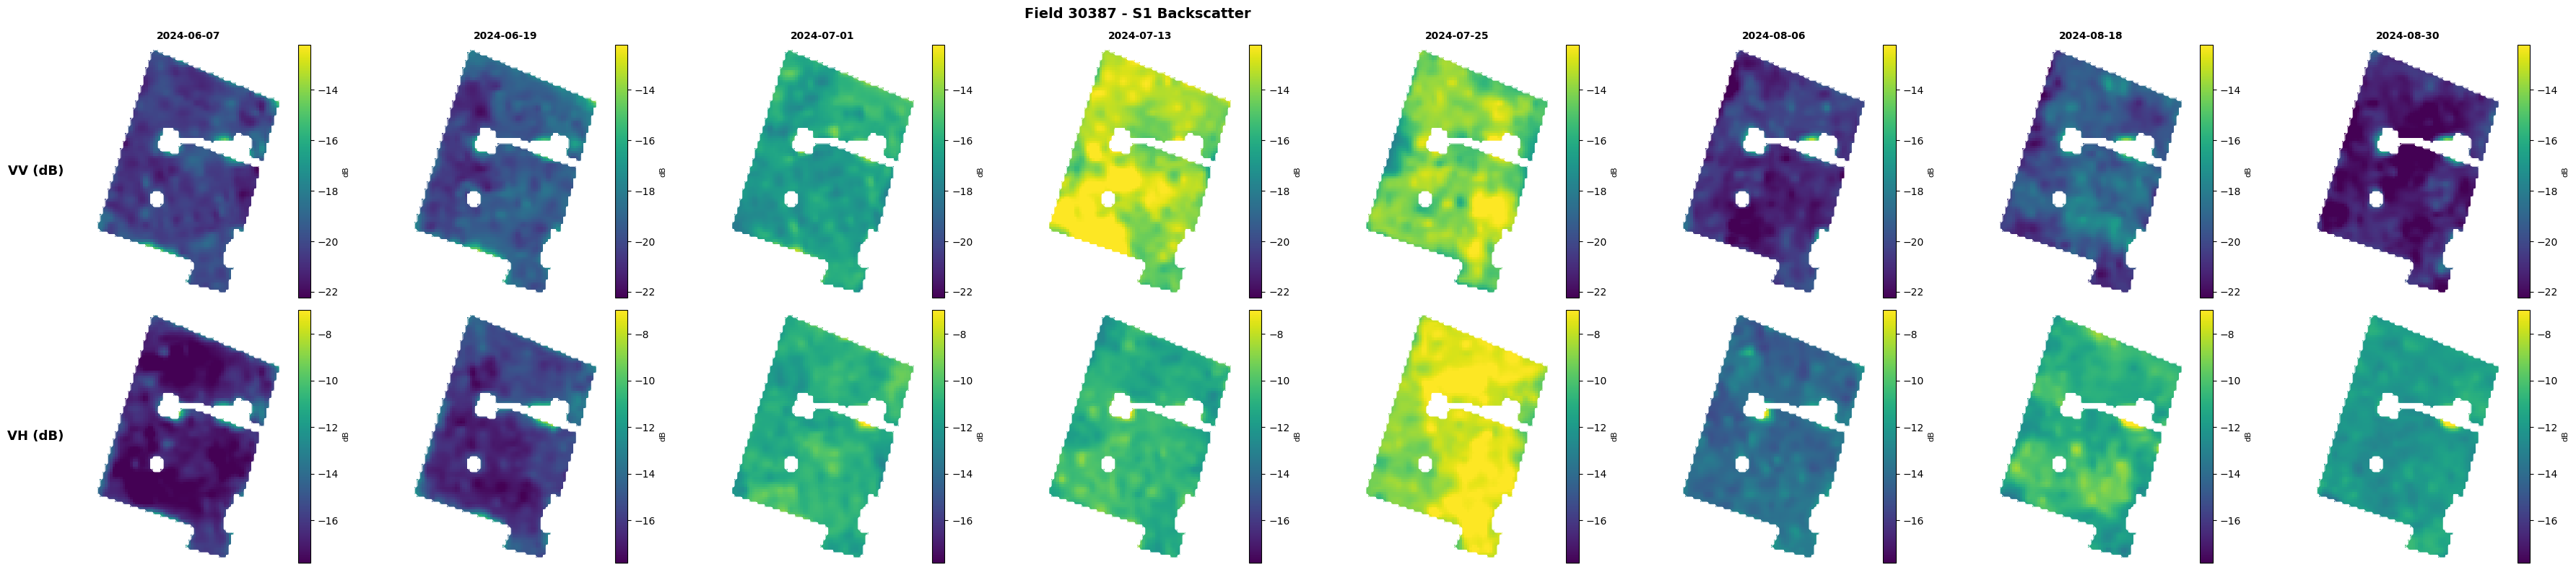

Saved: field_s1_bs.png


In [18]:
if len(bs_data) > 0:
    dates = sorted(bs_data.keys())
    n = len(dates)
    fig, axes = plt.subplots(2, n, figsize=(5*n, 8))
    if n == 1: axes = axes.reshape(-1, 1)
    else: axes = axes.T
    
    band_labels = ['VV (dB)', 'VH (dB)']
    
    for band_idx in range(2):
        vals = [bs_data[d][band_idx][mask_data==1] for d in dates]
        vmin, vmax = np.nanpercentile(np.concatenate(vals), [2, 98])
        
        for col_idx, date in enumerate(dates):
            ax = axes[col_idx, band_idx] if n > 1 else axes[col_idx]
            data = np.full_like(bs_data[date][band_idx], np.nan, dtype=float)
            data[mask_data==1] = bs_data[date][band_idx][mask_data==1]
            im = ax.imshow(data, cmap='viridis', vmin=vmin, vmax=vmax)
            ax.contour(mask_data, levels=[0.5], colors='white', linewidths=1, alpha=0.7)
            
            if col_idx == 0:
                ax.text(-0.15, 0.5, band_labels[band_idx], transform=ax.transAxes, fontweight='bold', fontsize=13, va='center', ha='right')
            if band_idx == 0:
                ax.set_title(date.strftime('%Y-%m-%d'), fontweight='bold', fontsize=10)
            ax.axis('off')
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('dB', fontsize=8)
    
    fig.suptitle(f'Field {FIELD_ID} - S1 Backscatter', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(left=0.1)
    plt.savefig('field_s1_bs.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: field_s1_bs.png')
else:
    print('No S1 backscatter data found')

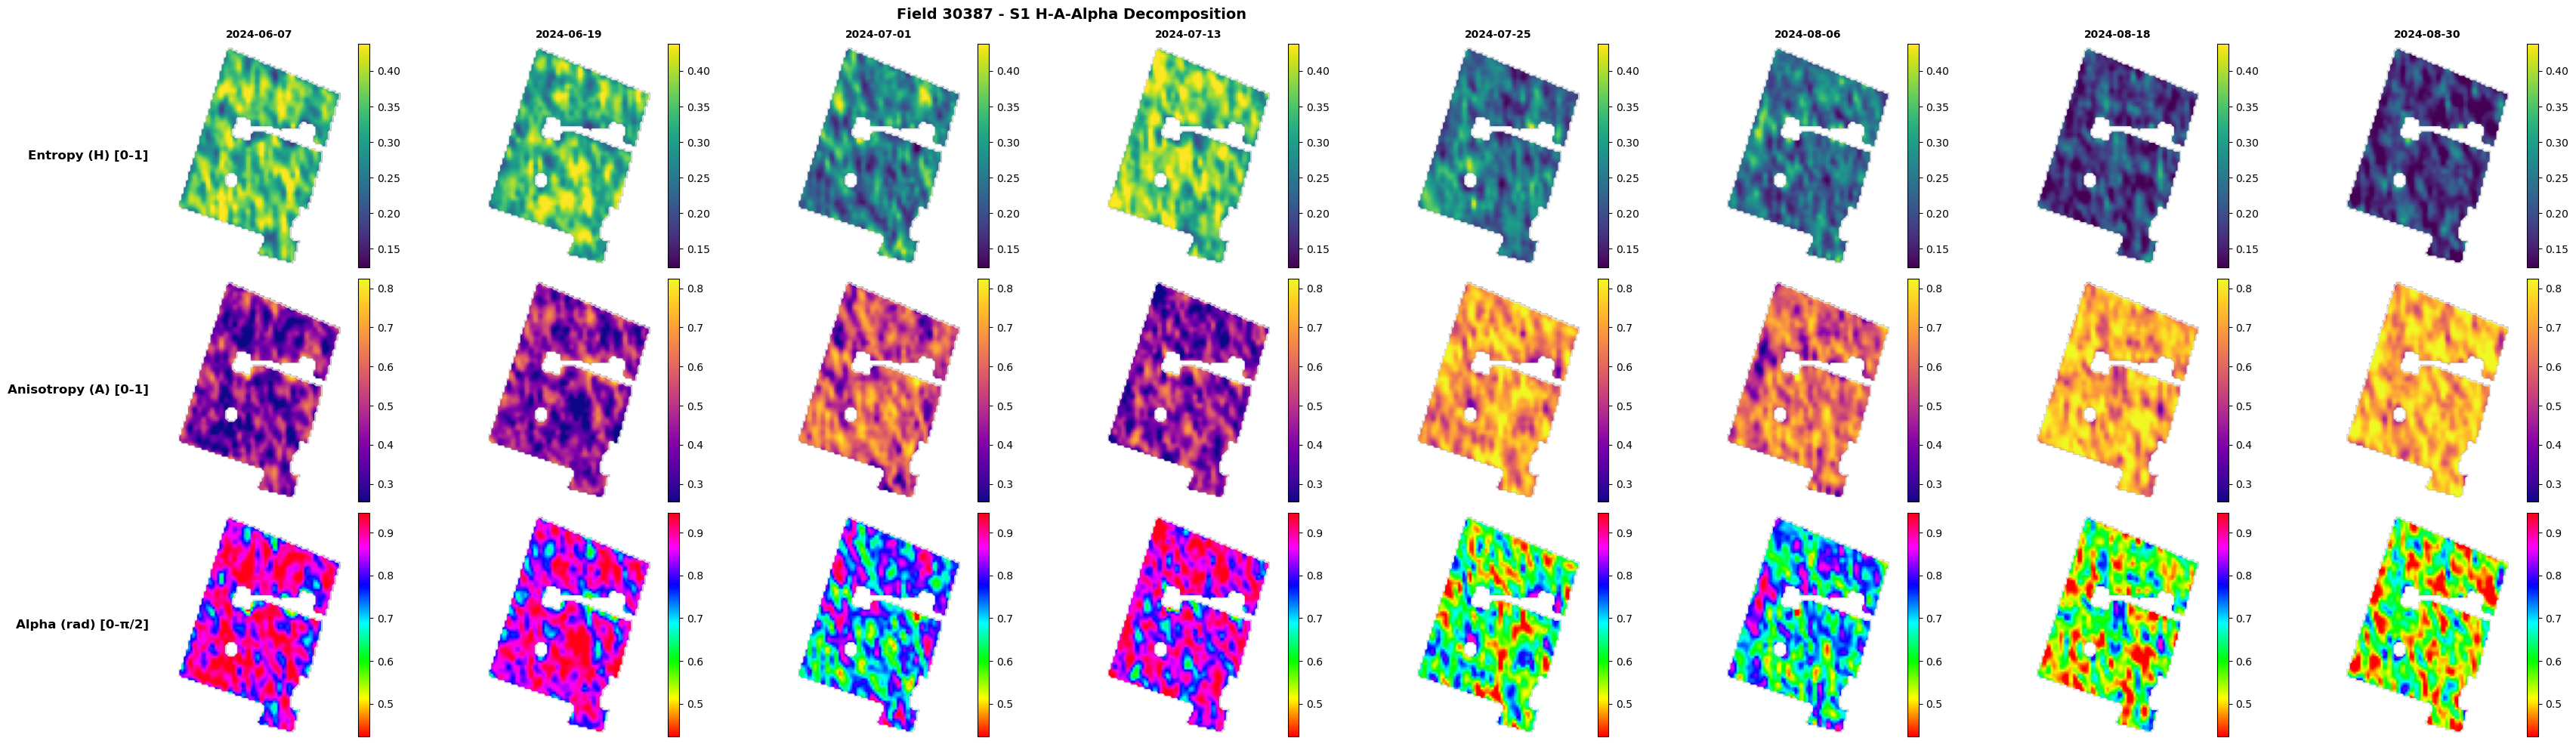

Saved: field_s1_haalpha.png


In [19]:
if len(pol_data) > 0:
    dates = sorted(pol_data.keys())
    n = len(dates)
    fig, axes = plt.subplots(3, n, figsize=(5*n, 10))
    if n == 1: axes = axes.reshape(-1, 1)
    else: axes = axes.T
    
    band_labels = ['Entropy (H) [0-1]', 'Anisotropy (A) [0-1]', 'Alpha (rad) [0-π/2]']
    cmaps = ['viridis', 'plasma', 'hsv']
    
    for band_idx in range(3):
        vals = [pol_data[d][band_idx][mask_data==1] for d in dates]
        vmin, vmax = np.nanpercentile(np.concatenate(vals), [2, 98])
        
        for col_idx, date in enumerate(dates):
            ax = axes[col_idx, band_idx] if n > 1 else axes[col_idx]
            data = np.full_like(pol_data[date][band_idx], np.nan, dtype=float)
            data[mask_data==1] = pol_data[date][band_idx][mask_data==1]
            im = ax.imshow(data, cmap=cmaps[band_idx], vmin=vmin, vmax=vmax)
            ax.contour(mask_data, levels=[0.5], colors='white', linewidths=1, alpha=0.7)
            
            if col_idx == 0:
                ax.text(-0.15, 0.5, band_labels[band_idx], transform=ax.transAxes, fontweight='bold', fontsize=12, va='center', ha='right')
            if band_idx == 0:
                ax.set_title(date.strftime('%Y-%m-%d'), fontweight='bold', fontsize=10)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    fig.suptitle(f'Field {FIELD_ID} - S1 H-A-Alpha Decomposition', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(left=0.15)
    plt.savefig('field_s1_haalpha.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: field_s1_haalpha.png')
else:
    print('No S1 H-A-Alpha data found')

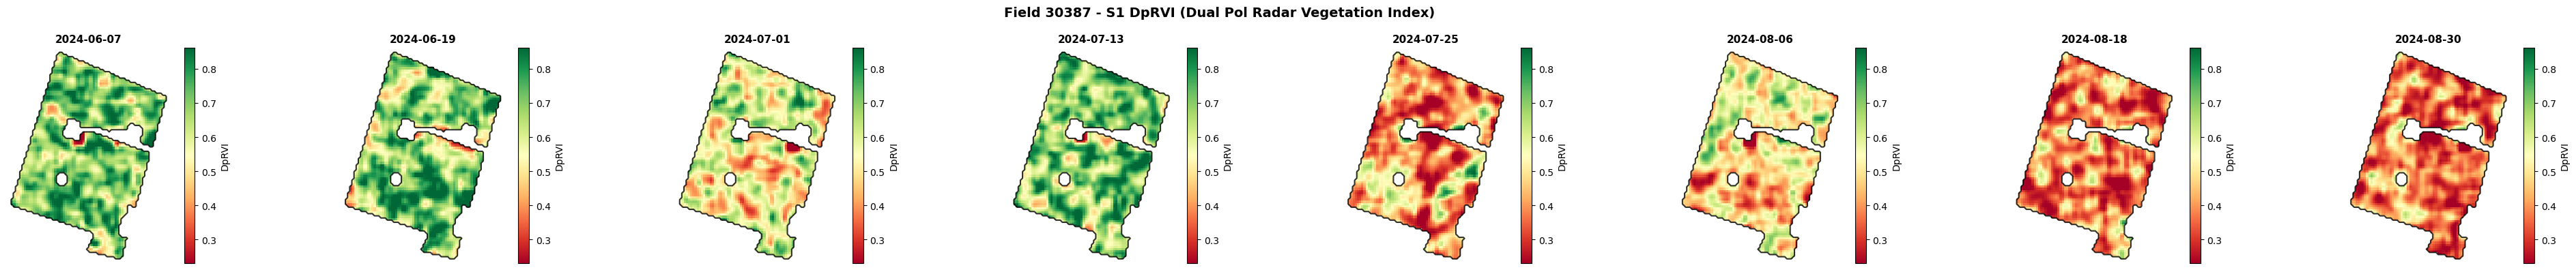

Saved: field_s1_dprvi.png


In [20]:
if len(dprvi_data) > 0:
    dates = sorted(dprvi_data.keys())
    n = len(dates)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    
    vals = [dprvi_data[d][0][mask_data==1] for d in dates]
    vmin, vmax = np.nanpercentile(np.concatenate(vals), [2, 98])
    
    for idx, date in enumerate(dates):
        data = np.full_like(dprvi_data[date][0], np.nan, dtype=float)
        data[mask_data==1] = dprvi_data[date][0][mask_data==1]
        im = axes[idx].imshow(data, cmap='RdYlGn', vmin=vmin, vmax=vmax)
        axes[idx].contour(mask_data, levels=[0.5], colors='black', linewidths=1.5, alpha=0.8)
        axes[idx].set_title(date.strftime('%Y-%m-%d'), fontweight='bold', fontsize=11)
        axes[idx].axis('off')
        cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
        cbar.set_label('DpRVI', fontsize=10)
    
    fig.suptitle(f'Field {FIELD_ID} - S1 DpRVI (Dual Pol Radar Vegetation Index)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('field_s1_dprvi.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: field_s1_dprvi.png')
else:
    print('No S1 DpRVI data found')

In [21]:
dates_all = sorted(set(list(bs_data.keys()) + list(pol_data.keys()) + list(dprvi_data.keys())))
ts_vv = [np.nanmean(bs_data[d][0][mask_data==1]) if d in bs_data else np.nan for d in dates_all]
ts_vh = [np.nanmean(bs_data[d][1][mask_data==1]) if d in bs_data else np.nan for d in dates_all]
ts_h = [np.nanmean(pol_data[d][0][mask_data==1]) if d in pol_data else np.nan for d in dates_all]
ts_a = [np.nanmean(pol_data[d][1][mask_data==1]) if d in pol_data else np.nan for d in dates_all]
ts_alpha = [np.nanmean(pol_data[d][2][mask_data==1]) if d in pol_data else np.nan for d in dates_all]
ts_dprvi = [np.nanmean(dprvi_data[d][0][mask_data==1]) if d in dprvi_data else np.nan for d in dates_all]

df = pd.DataFrame({
    'Date': dates_all,
    'S1_VV_dB': ts_vv,
    'S1_VH_dB': ts_vh,
    'S1_Entropy_H': ts_h,
    'S1_Anisotropy_A': ts_a,
    'S1_Alpha_rad': ts_alpha,
    'S1_DpRVI': ts_dprvi
})

print('\n' + '='*90)
print(f'Field {FIELD_ID} - Time Series Summary')
print('='*90)
print(df.to_string(index=False))
print('='*90)

df.to_csv('field_30387_timeseries.csv', index=False)
print('\nSaved: field_30387_timeseries.csv')


Field 30387 - Time Series Summary
      Date   S1_VV_dB   S1_VH_dB  S1_Entropy_H  S1_Anisotropy_A  S1_Alpha_rad  S1_DpRVI
2024-06-07 -20.150930 -16.810415      0.347988         0.406354      0.859075  0.699538
2024-06-19 -19.472315 -15.828913      0.337941         0.422939      0.849520  0.689383
2024-07-01 -16.441658 -10.926600      0.261989         0.561812      0.738280  0.555545
2024-07-13 -13.363692 -10.811572      0.364950         0.422135      0.849149  0.696537
2024-07-25 -14.140068  -7.836066      0.245461         0.687314      0.608815  0.416981
2024-08-06 -20.765837 -13.945457      0.240053         0.601943      0.702116  0.513300
2024-08-18 -19.350401 -10.773181      0.181425         0.716747      0.572539  0.377452
2024-08-30 -21.371431 -11.910959      0.172903         0.728251      0.558624  0.368034

Saved: field_30387_timeseries.csv


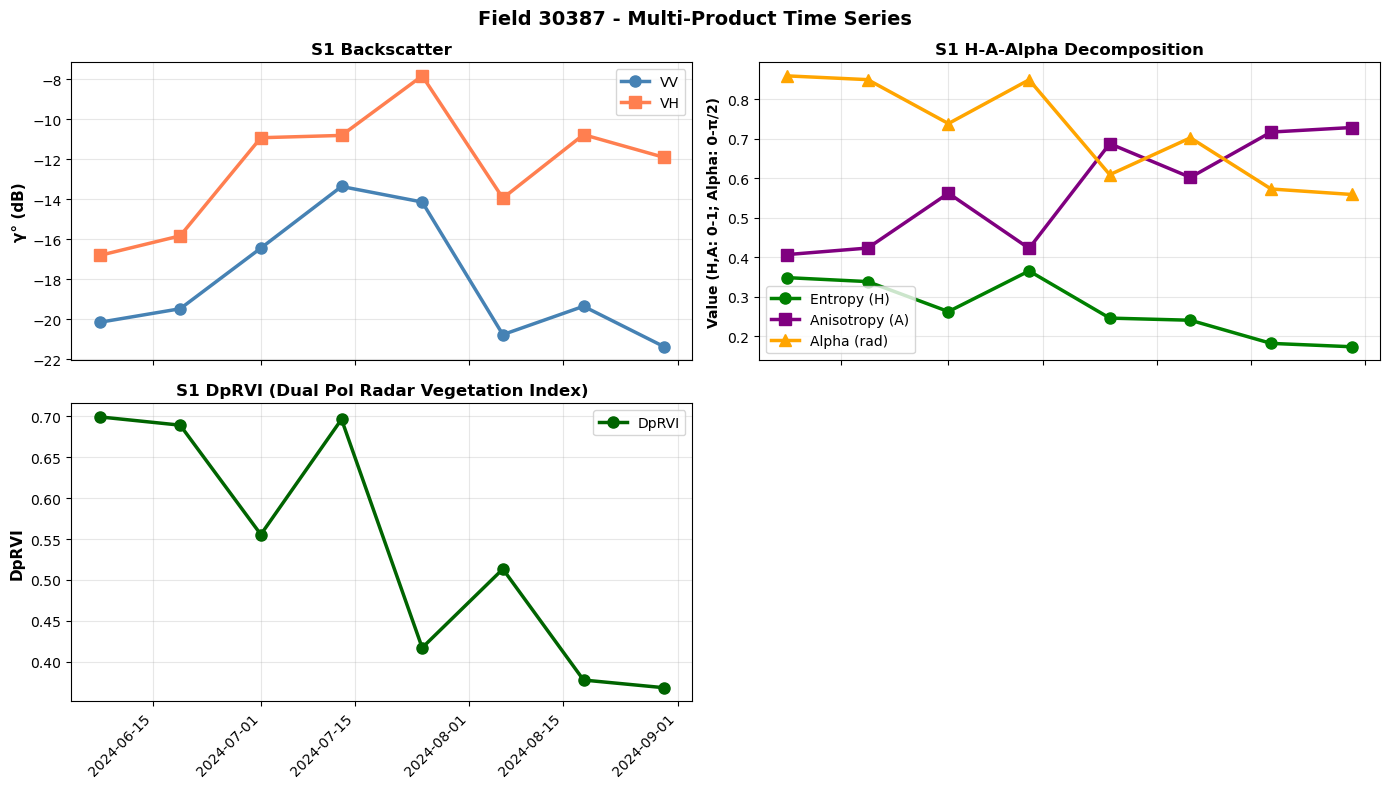

Saved: field_summary.png


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(dates_all, ts_vv, 'o-', label='VV', linewidth=2.5, markersize=8, color='steelblue')
axes[0,0].plot(dates_all, ts_vh, 's-', label='VH', linewidth=2.5, markersize=8, color='coral')
axes[0,0].set_title('S1 Backscatter', fontweight='bold', fontsize=12)
axes[0,0].set_ylabel('γ° (dB)', fontweight='bold', fontsize=11)
axes[0,0].legend(fontsize=10, loc='best')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(dates_all, ts_h, 'o-', label='Entropy (H)', linewidth=2.5, markersize=8, color='green')
axes[0,1].plot(dates_all, ts_a, 's-', label='Anisotropy (A)', linewidth=2.5, markersize=8, color='purple')
axes[0,1].plot(dates_all, ts_alpha, '^-', label='Alpha (rad)', linewidth=2.5, markersize=8, color='orange')
axes[0,1].set_title('S1 H-A-Alpha Decomposition', fontweight='bold', fontsize=12)
axes[0,1].set_ylabel('Value (H,A: 0-1; Alpha: 0-π/2)', fontweight='bold', fontsize=10)
axes[0,1].legend(fontsize=10, loc='best')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(dates_all, ts_dprvi, 'o-', color='darkgreen', linewidth=2.5, markersize=8, label='DpRVI')
axes[1,0].set_title('S1 DpRVI (Dual Pol Radar Vegetation Index)', fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('DpRVI', fontweight='bold', fontsize=11)
axes[1,0].legend(fontsize=10, loc='best')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].axis('off')

fig.suptitle(f'Field {FIELD_ID} - Multi-Product Time Series', fontsize=14, fontweight='bold')
fig.autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('field_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: field_summary.png')